## Visualizations for Zambia Data (Frozen Layer Finetune)

In [1]:
# https://claude.ai/share/569b84f1-9796-4e07-8ff9-cda6720d644f

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [4]:
# Load data
history = pd.read_csv('v1/checkpoints/unet_att_d_ep10/training_history.csv')
metrics = pd.read_csv('v1/checkpoints/finetune_metrics.csv')
classwise = pd.read_csv('v1/checkpoints/finetune_metrics_classwise.csv')

print('Training history shape:', history.shape)
print(history.head())
print('\nOverall metrics:')
print(metrics)
print('\nClass-wise metrics:')
print(classwise)

Training history shape: (10, 10)
   epoch  train_loss  val_loss      lr  overall_accuracy  mean_accuracy  \
0      1    0.665376  0.695947  0.0200          0.793808       0.676626   
1      2    0.655073  0.686550  0.0200          0.798440       0.676839   
2      3    0.645425  0.690640  0.0196          0.799966       0.672119   
3      4    0.639017  0.675374  0.0196          0.785106       0.697954   
4      5    0.630617  0.695975  0.0196          0.791982       0.662788   

   mean_iou  mean_precision  mean_recall  mean_f1_score  
0  0.514837        0.634865     0.676626       0.640280  
1  0.519417        0.639530     0.676839       0.644898  
2  0.519117        0.640479     0.672119       0.644451  
3  0.513446        0.632404     0.697954       0.639423  
4  0.508140        0.640266     0.662788       0.636174  

Overall metrics:
             Metric     Value
0  Overall Accuracy  0.806356
1     Mean Accuracy  0.645882
2          Mean IoU  0.514161
3    mean Precision  0.646638


### Loss Curves (Train vs Validation)

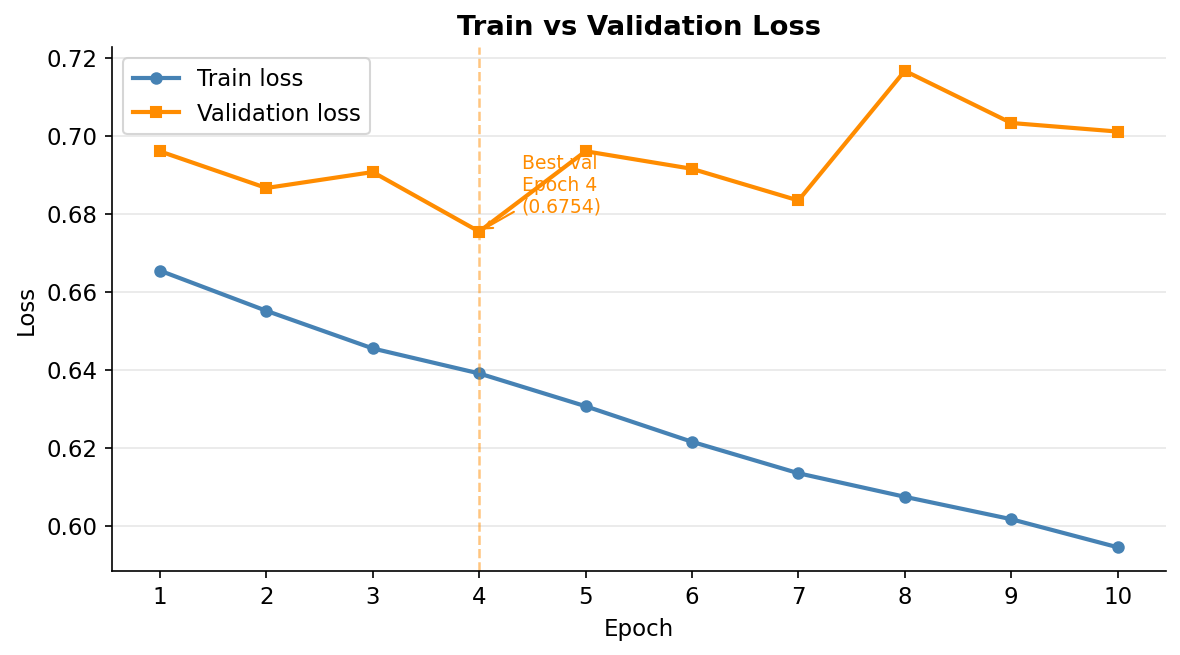

Saved → loss_curves.png


In [5]:
epochs = history['epoch']
best_epoch = history['val_loss'].idxmin() + 1  # 1-indexed
best_val   = history['val_loss'].min()

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(epochs, history['train_loss'], 'o-', color='steelblue',  label='Train loss',      linewidth=2, markersize=5)
ax.plot(epochs, history['val_loss'],   's-', color='darkorange', label='Validation loss', linewidth=2, markersize=5)

# Mark best validation epoch
ax.axvline(best_epoch, color='darkorange', linestyle='--', alpha=0.5, linewidth=1.2)
ax.annotate(f'Best val\nEpoch {best_epoch}\n({best_val:.4f})',
            xy=(best_epoch, best_val), xytext=(best_epoch + 0.4, best_val + 0.005),
            fontsize=9, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1))

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Validation Loss', fontweight='bold')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves.png', bbox_inches='tight')
plt.show()
print('Saved → loss_curves.png')

### Learning Rate Schedule

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

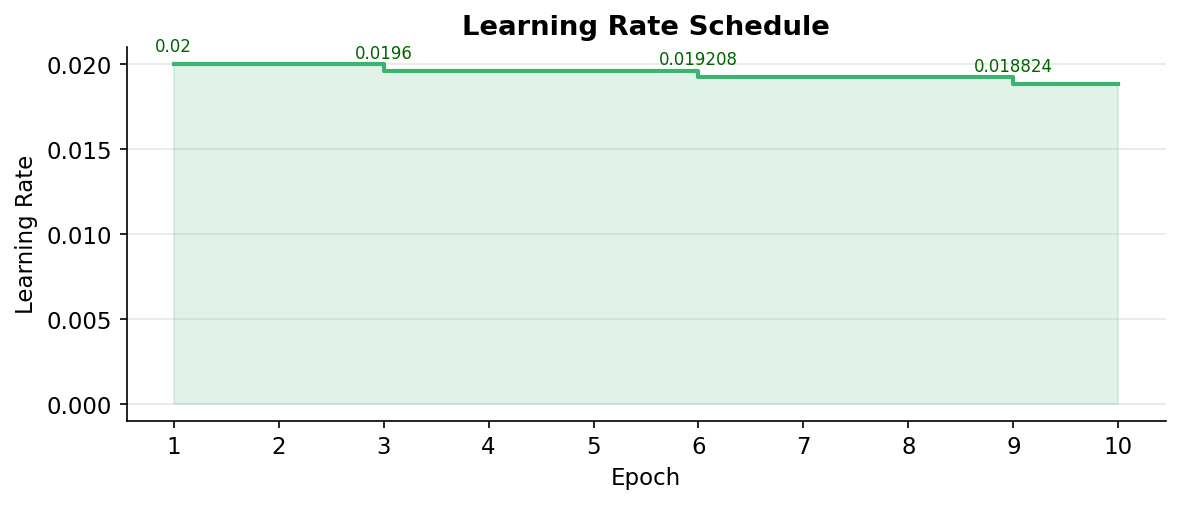

Saved → lr_schedule.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.step(epochs, history['lr'], where='post', color='mediumseagreen', linewidth=2)
ax.fill_between(epochs, history['lr'], step='post', alpha=0.15, color='mediumseagreen')

# Annotate each unique LR
prev = None
for _, row in history.iterrows():
    if row['lr'] != prev:
        ax.annotate(f"{row['lr']:.5g}", xy=(row['epoch'], row['lr']),
                    xytext=(0, 6), textcoords='offset points',
                    fontsize=8, ha='center', color='darkgreen')
        prev = row['lr']

ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule', fontweight='bold')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('lr_schedule.png', bbox_inches='tight')
plt.show()
print('Saved → lr_schedule.png')

### Validation Metrics per Epoch

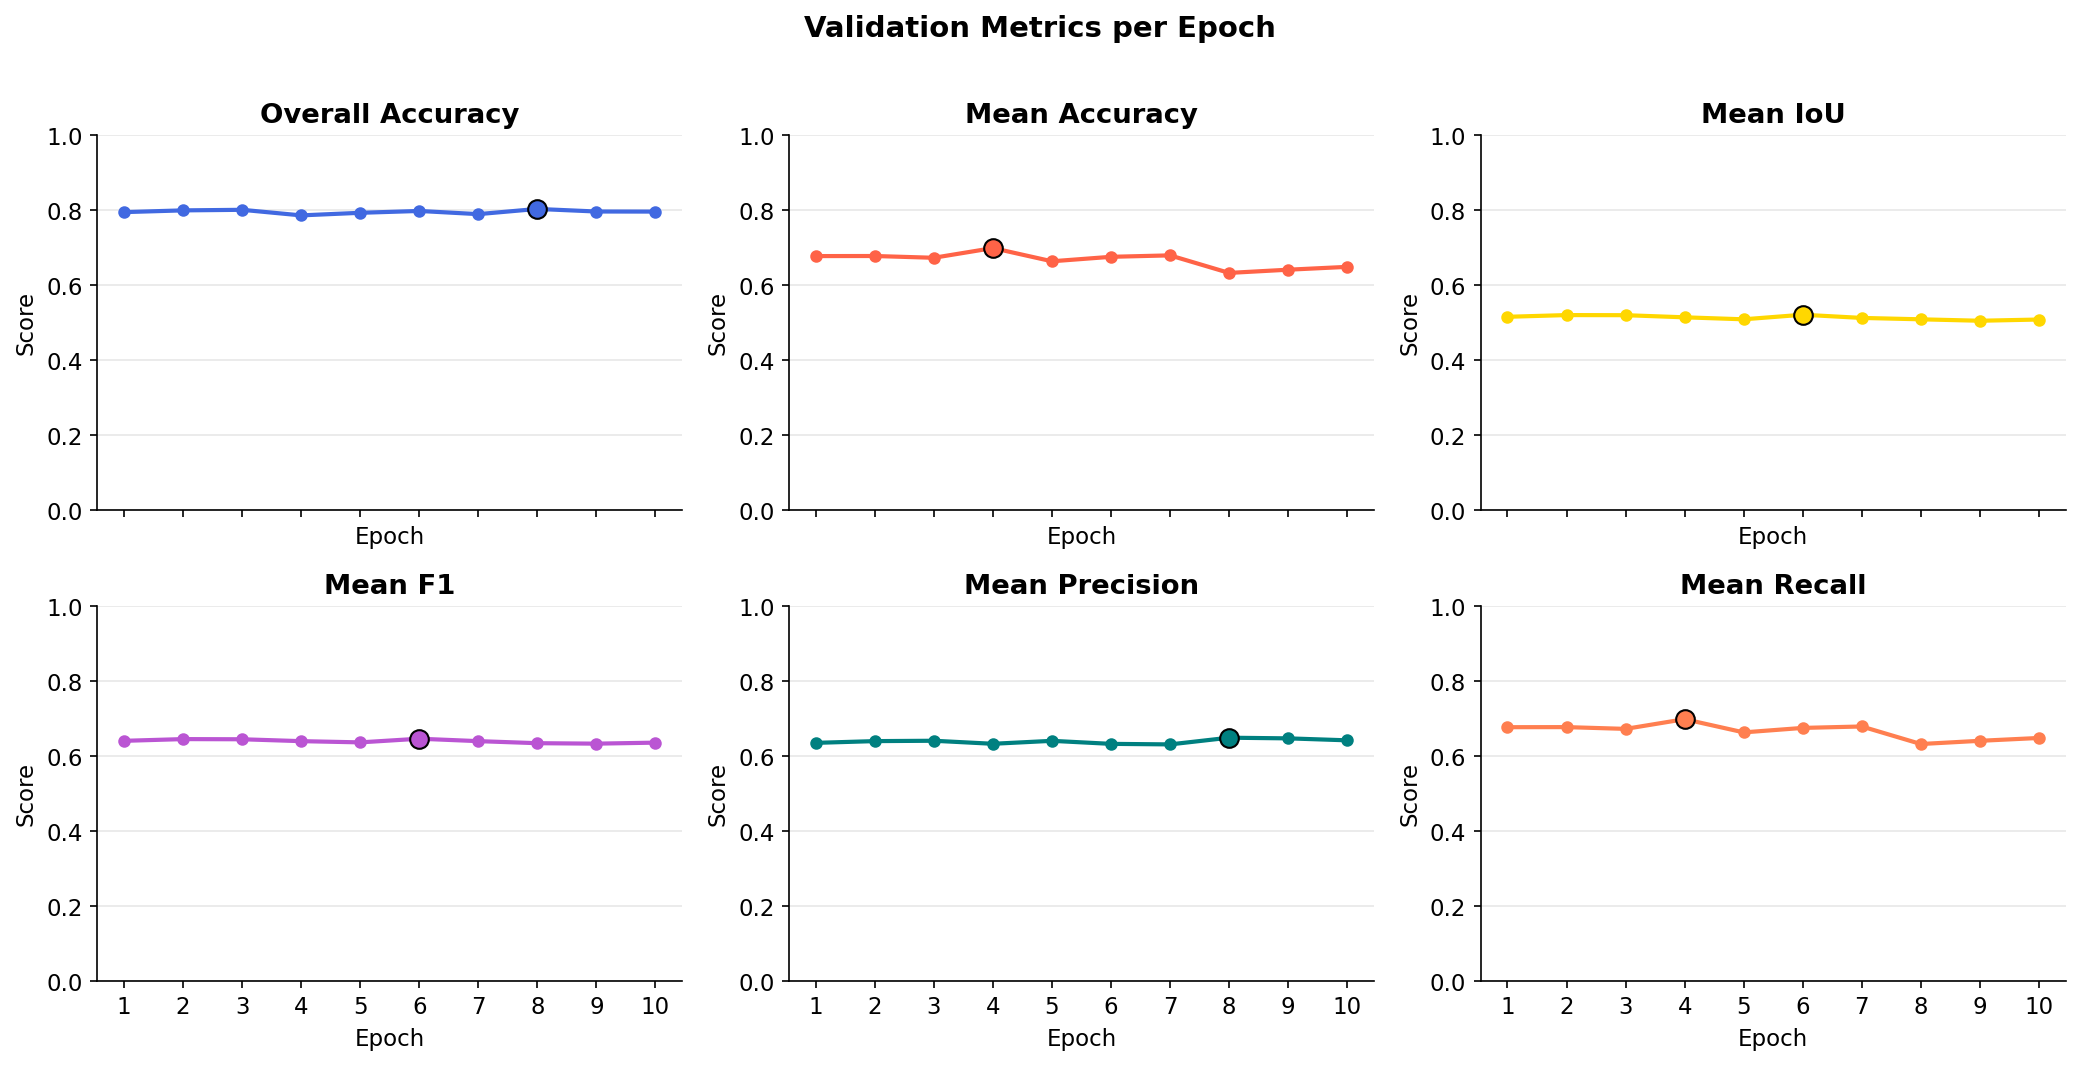

Saved → val_metrics_per_epoch.png


In [15]:
val_metrics = [
    ('overall_accuracy', 'Overall Accuracy', 'royalblue'),
    ('mean_accuracy',    'Mean Accuracy',    'tomato'),
    ('mean_iou',         'Mean IoU',         'gold'),
    ('mean_f1_score',    'Mean F1',          'mediumorchid'),
    ('mean_precision',   'Mean Precision',   'teal'),
    ('mean_recall',      'Mean Recall',      'coral'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
axes = axes.flatten()

for ax, (col, label, color) in zip(axes, val_metrics):
    ax.plot(epochs, history[col], 'o-', color=color, linewidth=2, markersize=5)
    best_idx = history[col].idxmax()
    ax.scatter(history.loc[best_idx, 'epoch'], history.loc[best_idx, col],
               s=80, zorder=5, color=color, edgecolors='black', linewidth=1)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_xlabel('Epoch')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1)

fig.suptitle('Validation Metrics per Epoch', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('val_metrics_per_epoch.png', bbox_inches='tight')
plt.show()
print('Saved → val_metrics_per_epoch.png')

In [19]:
print(history.columns)

Index(['epoch', 'train_loss', 'val_loss', 'lr', 'overall_accuracy',
       'mean_accuracy', 'mean_iou', 'mean_precision', 'mean_recall',
       'mean_f1_score'],
      dtype='object')


### Overall Metrics

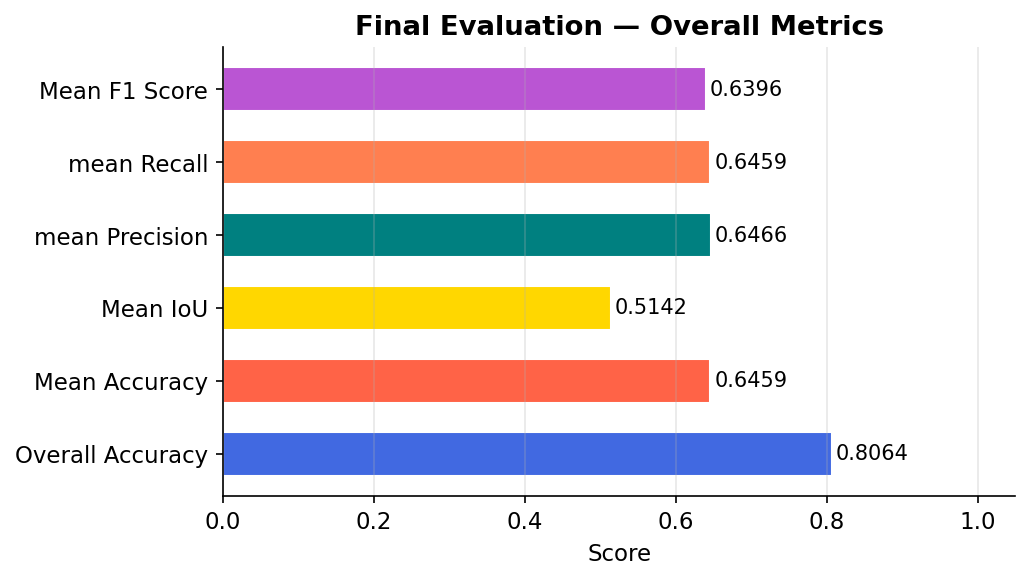

Saved → overall_metrics.png


In [16]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = ['royalblue', 'tomato', 'gold', 'teal', 'coral', 'mediumorchid']
bars = ax.barh(metrics['Metric'], metrics['Value'], color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, metrics['Value']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_xlim(0, 1.05)
ax.set_xlabel('Score')
ax.set_title('Final Evaluation — Overall Metrics', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('overall_metrics.png', bbox_inches='tight')
plt.show()
print('Saved → overall_metrics.png')

### Classwise Metrics

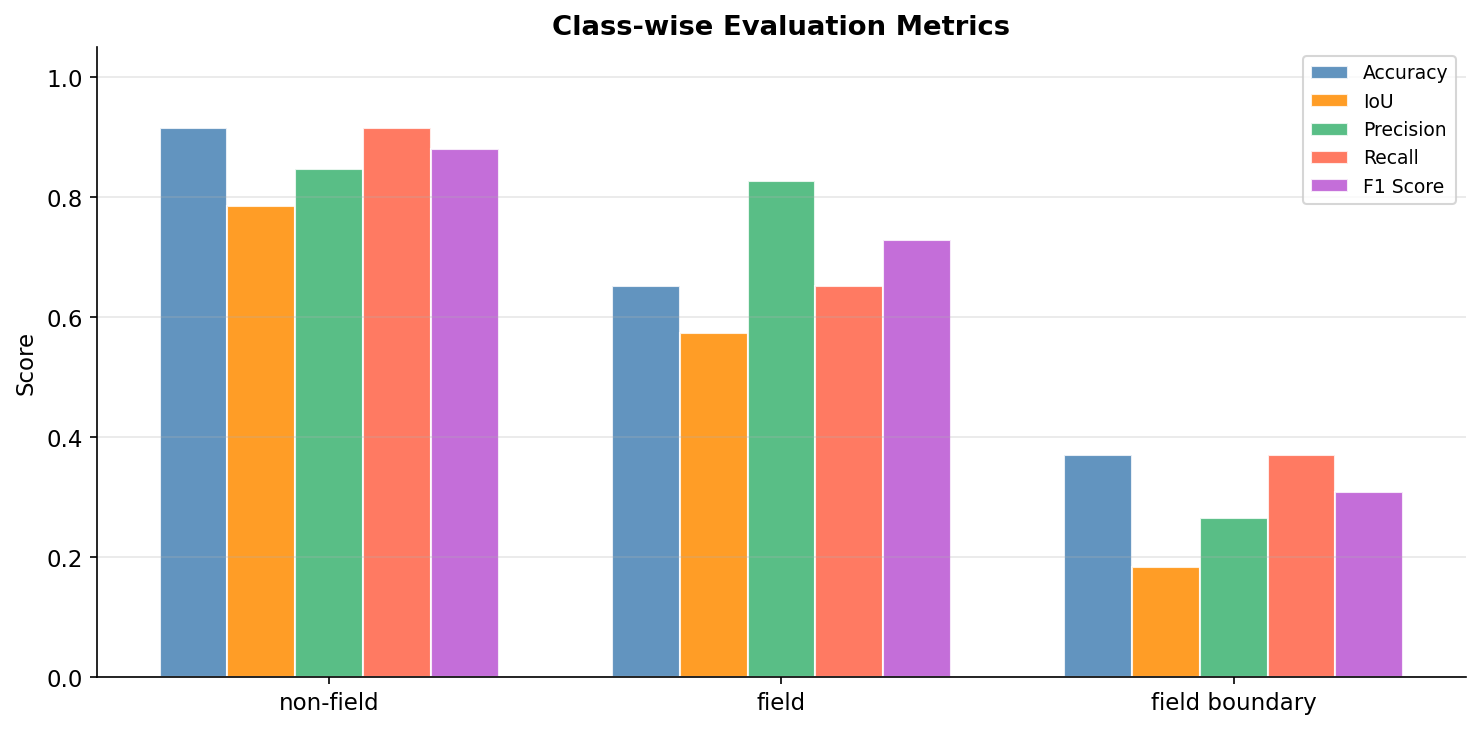

Saved → classwise_metrics.png


In [17]:
cw_metrics = ['Accuracy', 'IoU', 'Precision', 'Recall', 'F1 Score']
classes    = classwise['Class'].tolist()
x          = np.arange(len(classes))
width      = 0.15
colors     = ['steelblue', 'darkorange', 'mediumseagreen', 'tomato', 'mediumorchid']

fig, ax = plt.subplots(figsize=(10, 5))

for i, (metric, color) in enumerate(zip(cw_metrics, colors)):
    offset = (i - 2) * width
    rects = ax.bar(x + offset, classwise[metric], width, label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Class-wise Evaluation Metrics', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('classwise_metrics.png', bbox_inches='tight')
plt.show()
print('Saved → classwise_metrics.png')

### Summary Dashboard

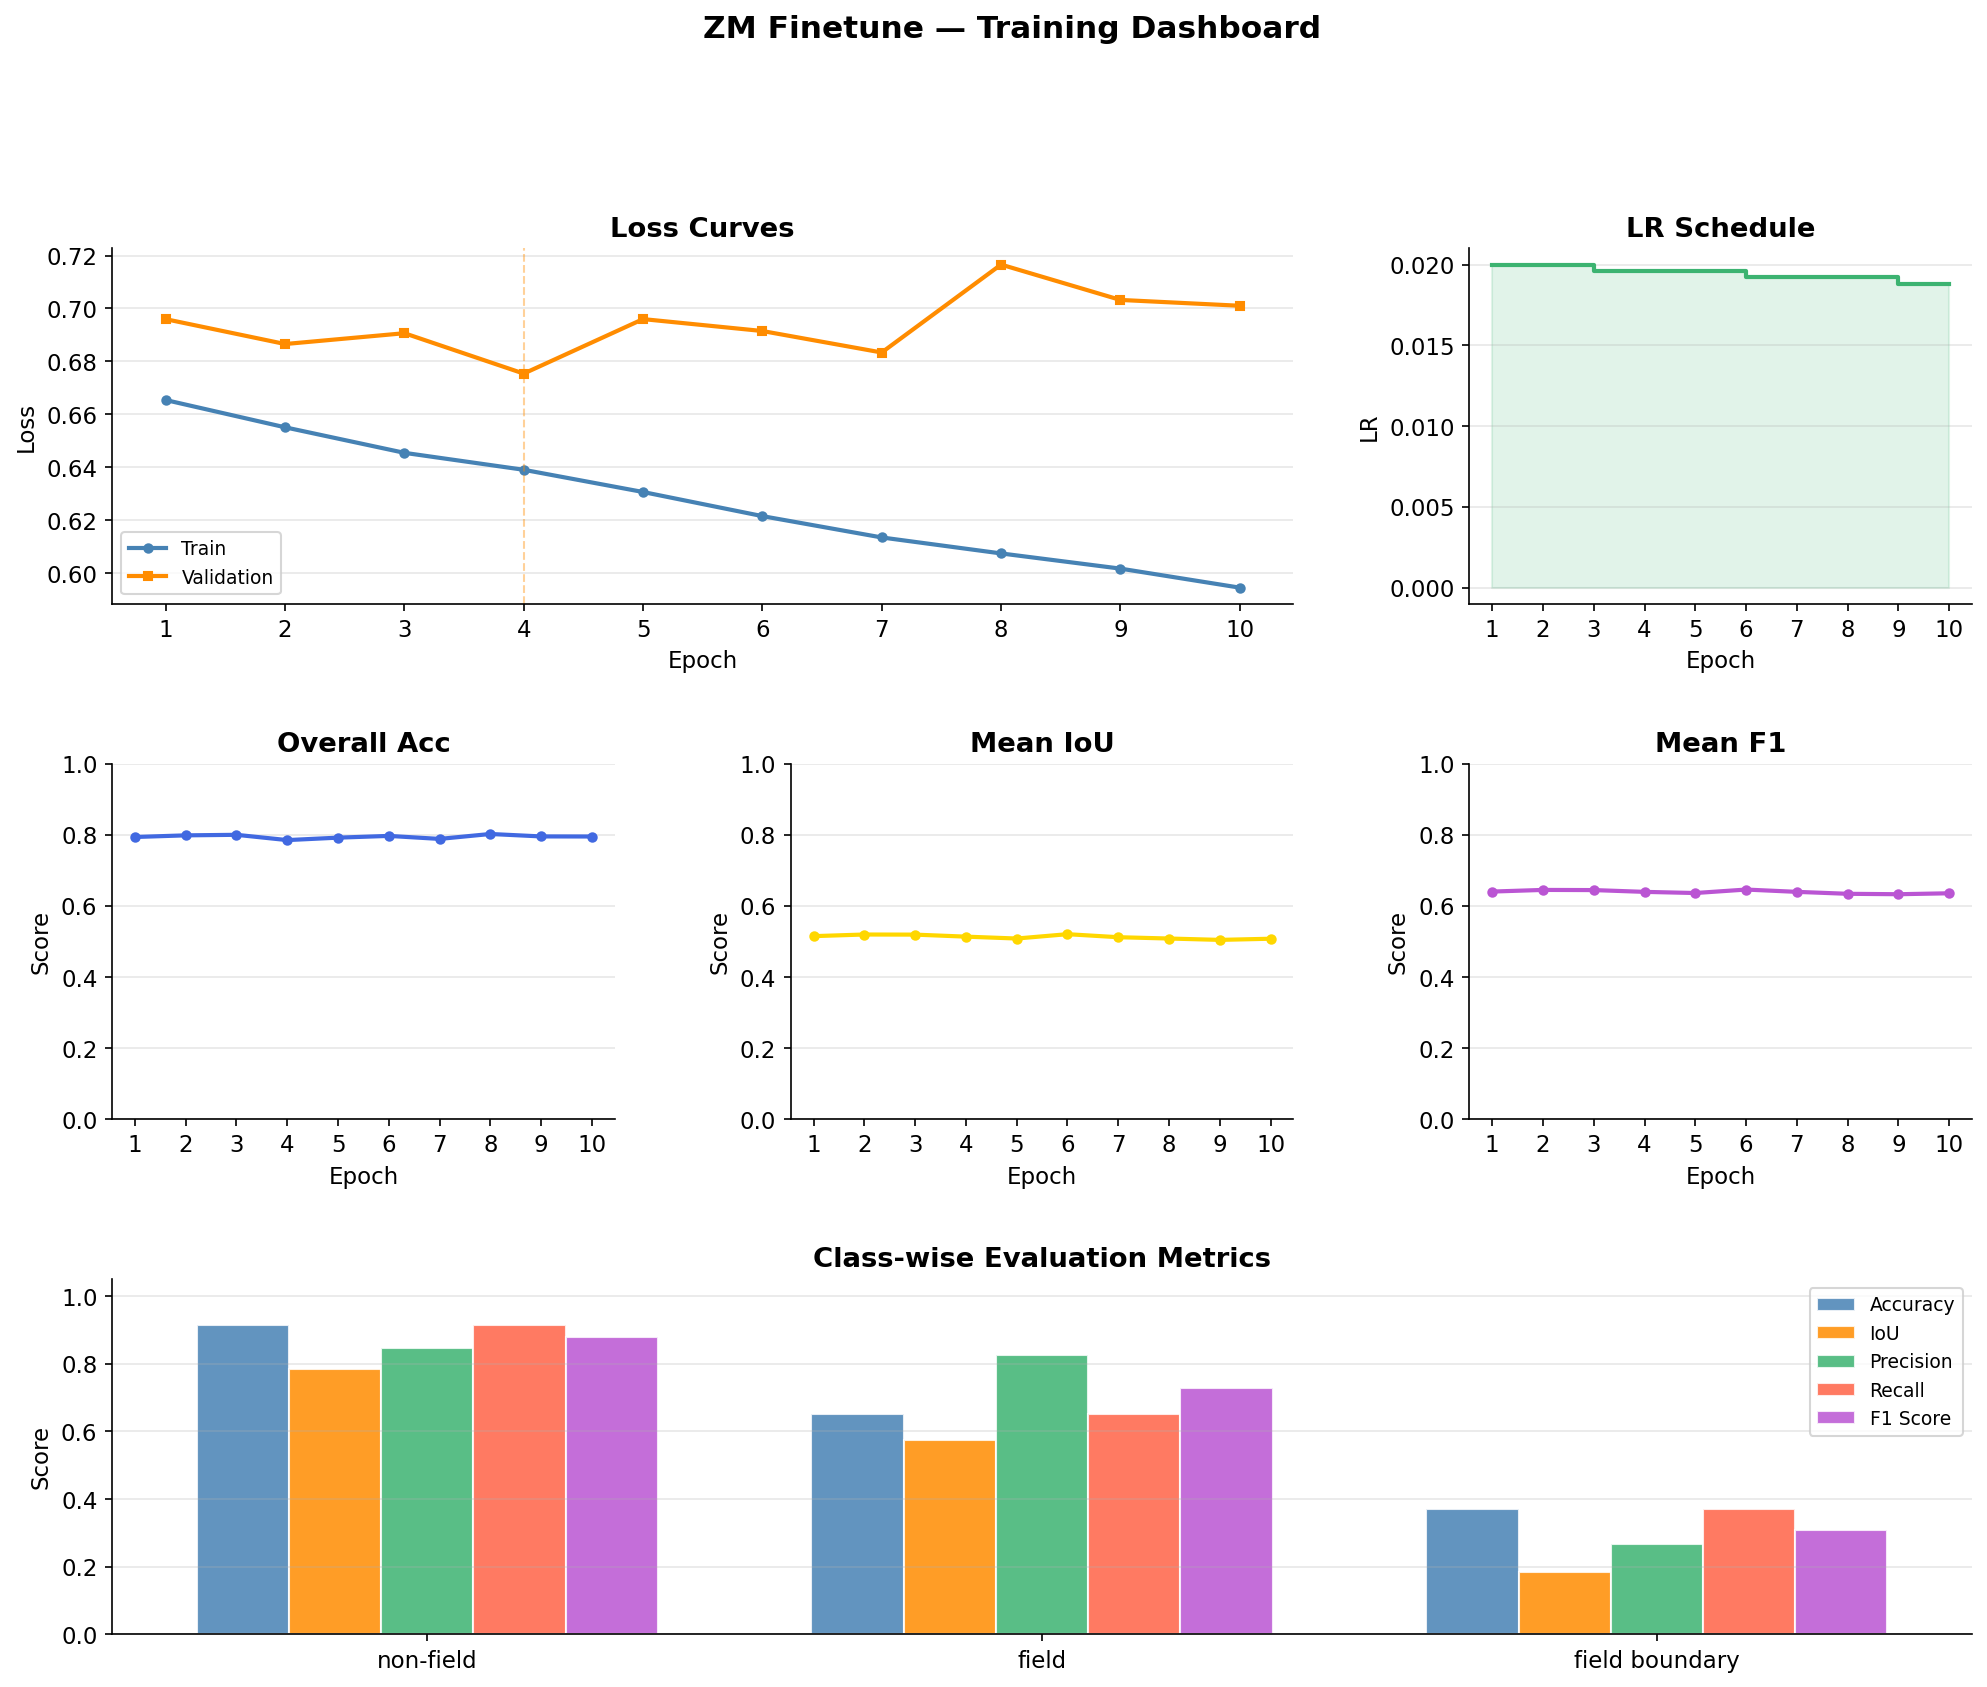

Saved → training_dashboard.png


In [18]:
fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# --- Loss curves (top-left, span 2 cols) ---
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(epochs, history['train_loss'], 'o-', color='steelblue',  label='Train',      lw=2, ms=4)
ax1.plot(epochs, history['val_loss'],   's-', color='darkorange', label='Validation', lw=2, ms=4)
ax1.axvline(best_epoch, color='darkorange', ls='--', alpha=0.4, lw=1)
ax1.set_title('Loss Curves', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- LR schedule (top-right) ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.step(epochs, history['lr'], where='post', color='mediumseagreen', lw=2)
ax2.fill_between(epochs, history['lr'], step='post', alpha=0.15, color='mediumseagreen')
ax2.set_title('LR Schedule', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('LR')
ax2.grid(axis='y', alpha=0.3)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- Val metrics per epoch (middle row) ---
mid_metrics = [('overall_accuracy','Overall Acc','royalblue'),
               ('mean_iou','Mean IoU','gold'),
               ('mean_f1_score','Mean F1','mediumorchid')]
for j, (col, lbl, clr) in enumerate(mid_metrics):
    ax = fig.add_subplot(gs[1, j])
    ax.plot(epochs, history[col], 'o-', color=clr, lw=2, ms=4)
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
    ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# --- Class-wise bars (bottom row, full width) ---
ax_cw = fig.add_subplot(gs[2, :])
for i, (metric, color) in enumerate(zip(cw_metrics, colors)):
    offset = (i - 2) * width
    ax_cw.bar(x + offset, classwise[metric], width, label=metric, color=color, alpha=0.85, edgecolor='white')
ax_cw.set_xticks(x)
ax_cw.set_xticklabels(classes)
ax_cw.set_ylim(0, 1.05)
ax_cw.set_ylabel('Score')
ax_cw.set_title('Class-wise Evaluation Metrics', fontweight='bold')
ax_cw.legend(loc='upper right', fontsize=9)
ax_cw.grid(axis='y', alpha=0.3)

fig.suptitle('ZM Finetune — Training Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('training_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved → training_dashboard.png')